In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
asample2 = pd.read_csv("../data/asample2_withlag.csv")

In [3]:
asample2

,Cm_ltotalincome,Cm_lhourlywage,Cm_lfamilyincome,Cm_pemployed,Cm_sei,flag_unemp,Bset1_year1,Bset1_doi_employed1,Bset1_doi_employedmf1,Bset1_doi_hours_worked1,...,Aset1_Motherocc2_1979_4,Aset1_Motherocc2_1979_5,Aset1_Motherocc2_1979_7,Aset1_Motherocc2_1979_8,Aset1_Motherocc2_1979_9,Aset1_Motherocc2_1979_10,Aset1_mfFatherocc2_1979_0,Aset1_mfFatherocc2_1979_1,Aset1_mfMotherocc2_1979_0,Aset1_mfMotherocc2_1979_1
0,4.217487,1.977451,9.881452,0.666667,22.100000,0,1984,1,0,2,...,0,0,0,0,0,0,1,0,1,0
1,5.129690,1.991274,10.861930,1.000000,35.947498,0,1987,0,0,0,...,0,0,0,0,0,1,1,0,1,0
2,10.969552,3.398430,11.380778,1.000000,39.470001,0,1986,1,0,2,...,1,0,0,0,0,0,1,0,1,0
3,6.615533,2.511609,10.002362,0.333333,28.196667,0,1990,1,0,1,...,1,0,0,0,0,0,0,1,1,0
4,10.207645,2.567574,10.332740,1.000000,42.114998,0,1984,1,0,2,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7458,9.654572,1.816562,9.763045,1.000000,48.759998,0,1987,1,0,2,...,0,0,0,0,0,0,1,0,1,0
7459,0.000000,1.405642,0.000000,0.000000,15.074862,1,1982,0,0,0,...,0,0,0,0,0,0,1,0,1,0
7460,9.327805,2.223070,10.282804,1.000000,16.370001,0,1984,0,0,0,...,0,0,0,0,0,0,1,0,1,0
7461,10.226488,2.260700,10.944498,1.000000,18.678333,0,1988,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [10]:
asample2.columns

Index(['Cm_ltotalincome', 'Cm_lhourlywage', 'Cm_lfamilyincome', 'Cm_pemployed',
       'Cm_sei', 'flag_unemp', 'Bset1_year1', 'Bset1_doi_employed1',
       'Bset1_doi_employedmf1', 'Bset1_doi_hours_worked1',
       ...
       'Aset1_Motherocc2_1979_4', 'Aset1_Motherocc2_1979_5',
       'Aset1_Motherocc2_1979_7', 'Aset1_Motherocc2_1979_8',
       'Aset1_Motherocc2_1979_9', 'Aset1_Motherocc2_1979_10',
       'Aset1_mfFatherocc2_1979_0', 'Aset1_mfFatherocc2_1979_1',
       'Aset1_mfMotherocc2_1979_0', 'Aset1_mfMotherocc2_1979_1'],
      dtype='str', length=4258)

In [9]:
asample2.info

<bound method DataFrame.info of       Cm_ltotalincome  Cm_lhourlywage  Cm_lfamilyincome  Cm_pemployed  \
0            4.217487        1.977451          9.881452      0.666667   
1            5.129690        1.991274         10.861930      1.000000   
2           10.969552        3.398430         11.380778      1.000000   
3            6.615533        2.511609         10.002362      0.333333   
4           10.207645        2.567574         10.332740      1.000000   
...               ...             ...               ...           ...   
7458         9.654572        1.816562          9.763045      1.000000   
7459         0.000000        1.405642          0.000000      0.000000   
7460         9.327805        2.223070         10.282804      1.000000   
7461        10.226488        2.260700         10.944498      1.000000   
7462         5.965204        2.058554          8.289134      0.833333   

         Cm_sei  flag_unemp  Bset1_year1  Bset1_doi_employed1  \
0     22.100000           

In [30]:
# there is already Aset, Bset, etc for variables... first try with just dif combinations of this as in the paper 
predictors_aset1 = [col for col in asample2.columns if "Aset1" in col ]
predictors_aset2 = [col for col in asample2.columns if "Aset2" in col]
predictors_bset1 = [col for col in asample2.columns if "Bset1" in col]
predictors_bset2 = [col for col in asample2.columns if "Bset2" in col]

predictors = [predictors_aset1, predictors_aset2, predictors_bset1, predictors_bset2]


In [31]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

model = xgb.XGBRegressor(
    n_estimators=90,
    max_depth=2,
    learning_rate=0.3,
    objective="reg:squarederror",
    verbosity=0
)

In [32]:
from sklearn.model_selection import train_test_split

results = []
current = []

predictors_all = [col for col in asample2.columns if "Aset" in col or "Bset" in col]

y = asample2["Cm_lhourlywage"]
X = asample2[predictors_all]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123)

y_mean = np.mean(y_train)
null_preds = np.full_like(y_test, y_mean)
null_mse = mean_squared_error(y_test, null_preds)

for s in [predictors_aset1, predictors_aset2, predictors_bset1, predictors_bset2]:
    current = list(dict.fromkeys(current + s))  # keep order, remove duplicates

    X_train_subset = X_train.loc[:, current]
    X_test_subset = X_test.loc[:, current]

    model.fit(X_train_subset, y_train)
    preds = model.predict(X_test_subset)
    mse = mean_squared_error(y_test, preds)
    r2 = 1 - mse / null_mse
    results.append({
        "n_features": len(current),
        "mse": mse,
        "r2": r2
    })

In [33]:
results

[{'n_features': 99, 'mse': 0.2928986883606522, 'r2': 0.22879571902455476},
 {'n_features': 515, 'mse': 0.24261171874600357, 'r2': 0.3612016593213807},
 {'n_features': 4195, 'mse': 0.17627359904511863, 'r2': 0.5358703892891616},
 {'n_features': 4251, 'mse': 0.1772000060203588, 'r2': 0.5334311532883811}]

In [34]:
# again, same as paper :) 
# plot? 
results_df = pd.DataFrame(results)

<Axes: xlabel='n_features'>

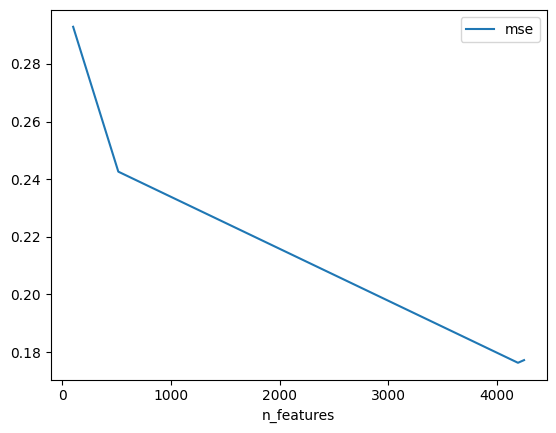

In [35]:
results_df.plot(x="n_features", y="mse")